In [ ]:
#Importing necessary libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [143]:
#Filter for Job Title and Country
job_titles = 'Data Analyst'
job_country = 'India'

In [144]:
df_Data_Jobs = df[(df['job_title_short'] == job_titles) & (df['job_country'] == job_country)].copy()

In [145]:
df_Data_Jobs['job_posted_month_no'] = df_Data_Jobs['job_posted_date'].dt.month

In [146]:
df_Data_Jobs_exploded = df_Data_Jobs.explode('job_skills')

In [147]:
df_Data_Jobs_pivot = df_Data_Jobs_exploded.pivot_table(index = 'job_posted_month_no', columns = 'job_skills', aggfunc = 'size', fill_value = 0)

df_Data_Jobs_pivot.loc['Total'] = df_Data_Jobs_pivot.sum()

df_Data_Jobs_pivot = df_Data_Jobs_pivot[df_Data_Jobs_pivot.loc['Total'].sort_values(ascending = False).index]

df_Data_Jobs_pivot = df_Data_Jobs_pivot.drop('Total')


In [148]:
Data_Jobs_Total = df_Data_Jobs.groupby('job_posted_month_no').size()


In [149]:
df_Data_Jobs_Percentage = df_Data_Jobs_pivot.div(Data_Jobs_Total / 100, axis = 0)


In [150]:
df_Data_Jobs_Percentage = df_Data_Jobs_Percentage.reset_index()
df_Data_Jobs_Percentage['job_posted_month'] = df_Data_Jobs_Percentage['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%B'))
df_Data_Jobs_Percentage = df_Data_Jobs_Percentage.set_index('job_posted_month')
df_Data_Jobs_Percentage = df_Data_Jobs_Percentage.drop(columns = 'job_posted_month_no')
df_Data_Jobs_Percentage

job_skills,sql,python,excel,tableau,power bi,r,sas,azure,aws,powerpoint,...,ringcentral,rshiny,suse,ubuntu,twilio,typescript,vue.js,unreal,wrike,workfront
job_posted_month,,,,,,,,,,,,,,,,,,,,,
January,48.566879,34.394904,34.713376,25.318471,15.605096,14.171975,20.382166,7.324841,5.095541,6.847134,...,0.000000,0.000000,0.000000,0.000000,0.159236,0.000000,0.0,0.000000,0.000000,0.00000
February,48.267898,34.180139,36.027714,26.789838,17.321016,15.473441,18.937644,6.004619,7.621247,5.773672,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
March,54.265403,35.781991,32.701422,29.620853,18.009479,13.744076,14.691943,10.663507,9.004739,6.872038,...,0.000000,0.000000,0.236967,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
April,48.803828,34.210526,33.014354,23.444976,19.856459,13.397129,12.440191,9.569378,7.416268,6.698565,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
May,55.755396,36.330935,38.129496,25.539568,21.942446,15.107914,10.791367,11.870504,7.913669,6.834532,...,0.000000,0.359712,0.000000,0.000000,0.000000,0.000000,0.0,0.359712,0.000000,0.00000
June,52.588556,40.871935,31.335150,31.062670,20.980926,20.708447,20.163488,10.081744,8.719346,6.539510,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.27248
July,53.610503,35.229759,38.074398,27.133479,20.350109,14.660832,17.067834,8.533917,6.783370,6.783370,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
August,51.294498,34.951456,31.067961,24.595469,20.550162,18.122977,15.857605,8.414239,10.194175,6.472492,...,0.000000,0.000000,0.000000,0.161812,0.000000,0.000000,0.0,0.000000,0.000000,0.00000
September,54.126984,36.349206,36.190476,30.952381,26.666667,15.873016,14.603175,5.555556,6.507937,4.603175,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.00000


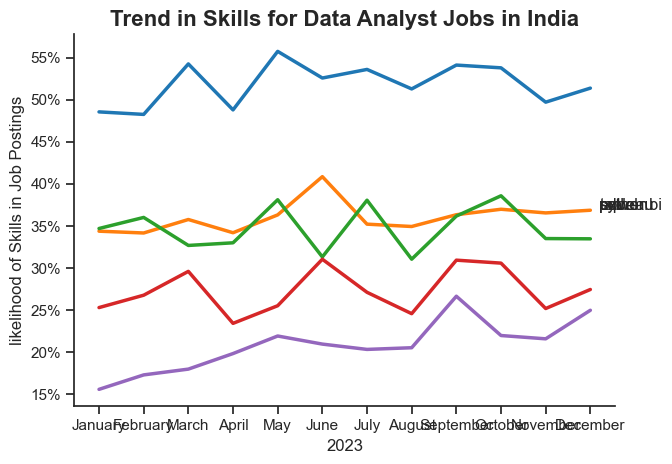

In [151]:
df_Plot = df_Data_Jobs_Percentage.iloc[:, :5]
sns.lineplot(data = df_Plot, dashes = False, palette = 'tab10', linewidth = 2.5)
sns.set_theme(style = 'ticks')
sns.despine()

plt.title(f'Trend in Skills for {job_titles} Jobs in {job_country}', fontsize = 16, fontweight = 'bold')
plt.xlabel('2023', fontsize = 12)
plt.ylabel('likelihood of Skills in Job Postings', fontsize = 12)
plt.legend().remove()
plt.tight_layout()
from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals = 0))
for i in range(5):
    plt.text(11.2, df_Plot.iloc[-1, 1], df_Plot.columns[i])



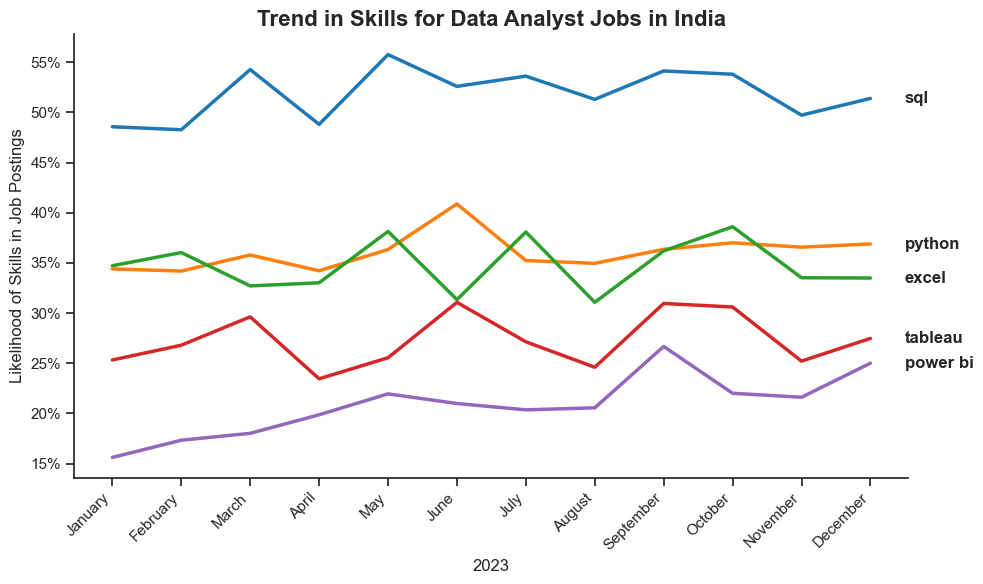

In [152]:
# Plotting
df_Plot = df_Data_Jobs_Percentage.iloc[:, :5]

# Set theme before plotting
sns.set_theme(style = 'ticks')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the lines
sns.lineplot(data = df_Plot, dashes = False, palette = 'tab10', linewidth = 2.5, ax=ax)

# Remove spines
sns.despine()

# Set titles and labels
plt.title(f'Trend in Skills for {job_titles} Jobs in {job_country}', fontsize = 16, fontweight = 'bold')
plt.xlabel('2023', fontsize = 12)
plt.ylabel('Likelihood of Skills in Job Postings', fontsize = 12)

# Format y-axis as percentage
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Fix x-axis to show month names clearly
ax.set_xticks(range(len(df_Plot.index)))
ax.set_xticklabels(df_Plot.index, rotation=45, ha='right')

# Remove default legend
plt.legend().remove()

# Add skill labels at the end of each line
for i, column in enumerate(df_Plot.columns):
    # Get the last value and position
    last_value = df_Plot[column].iloc[-1]
    # Add text label slightly to the right of the last point
    plt.text(len(df_Plot) - 0.5, last_value, column, 
             fontsize=12, va='center', fontweight='bold')

plt.tight_layout()
plt.show()